In [1]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

In [246]:
#------------------------------
# Geometrical Constants
#------------------------------

Rout = 15.0 #outer radius in mm
L0 = 1 #max height in mm
h = 2/5 #step height in mm
cl  = 6.7*1e6 #longitudinal wave speed in mm/s
ct  = 5.4*1e6 #transverse wave speed in mm/s
m   = 0

In [247]:
def L(r):
    return L0-h*(r/Rout)**2

In [248]:
Nr = 1000
rho = (np.arange(Nr) + 0.5)/Nr
drho = rho[1] - rho[0]

In [249]:
R0 = Rout

def ell(rho):
    r = R0*rho
    return L(r)/R0

In [250]:
rp = rho + drho/2
rm = rho - drho/2

main = (rp + rm)/(rho*drho**2)
upper = -rp/(rho*drho**2)
lower = -rm/(rho*drho**2)

# correggi i bordi per Neumann
main[0] = 2/drho**2
upper[0] = -2/drho**2
lower[0] = 0

main[-1] = 2/drho**2
lower[-1] = -2/drho**2
upper[-1] = 0

D = sp.diags(
    diagonals=[lower[1:], main, upper[:-1]],
    offsets=[-1, 0, 1],
    format="csr"
)

Text(0.5, 1.0, 'Effect of centrifugal term, N=1')

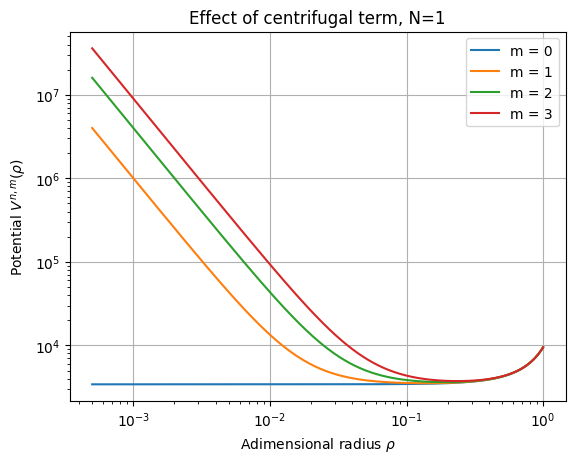

In [251]:
for emme in [0,1,2,3]:
    v = emme**2/rho**2 + (cl/ct)**2*(np.pi/ell(rho))**2
    plt.plot(rho, v, label=f'm = {emme}')
plt.loglog()
plt.xlabel(r'Adimensional radius $\rho$')
plt.ylabel(r'Potential $V^{n,m}(\rho)$')
plt.legend()
plt.grid()
plt.title('Effect of centrifugal term, N=1')

In [252]:
results = {
    "N": [1,3,5],
    "eigvecs": [],
    "eigvals": [],
    "omegas":[]
}

In [253]:
for n in results["N"]:
    def ell(rho):
        r = R0*rho
        return L(r)/R0

    V = m**2/rho**2 + (cl/ct)**2*(n*np.pi/ell(rho))**2
    A = D + sp.diags(V, 0)

    eigvals, eigvecs = spla.eigs(
        A,
        k=2,
        which="SM"
    )

    eigvals = np.real(eigvals)
    idx = np.argsort(eigvals)

    results["eigvals"].append(eigvals[idx])
    results["eigvecs"].append(eigvecs[:, idx])
    results["omegas"].append(np.sqrt(np.real(eigvals)))

In [254]:
from scipy.special import hermite
from numpy import sqrt, exp

In [255]:
def rho0(n):
    omega = n*np.pi*cl/L0
    return np.sqrt(ct/(omega*Rout) * np.sqrt(L0/(2*h)))*Rout

In [256]:
results["rho0s"] = [rho0(n) for n in results["N"]]
#results["kr2s"] = [kr2(rho, n, results["omegas"][n-1]) for n in results["N"]]
#results["kz2s"] = [kz2(rho, n) for n in results["N"]]

In [257]:
def psi_analytic(rho, N, rho0):
    psi = np.exp(-rho**2/(2*rho0**2))#*hermite(N)(rho)
    return psi

def normalize_cyl(psi, rho):
    norm = np.trapezoid(psi**2 * rho, rho)
    return psi / np.sqrt(norm)

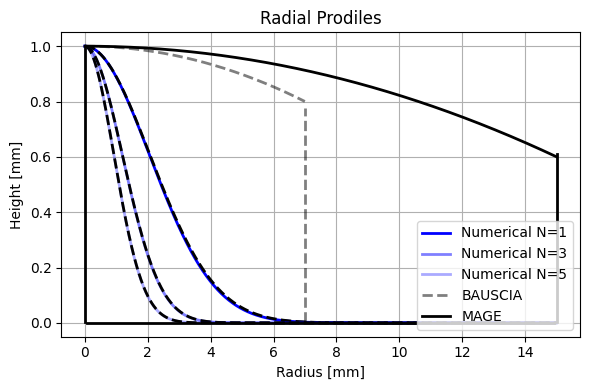

In [274]:
plt.figure(figsize=(6,4))
for i,n in enumerate(results["N"]):
    # numerical

    psi_num = normalize_cyl(results["eigvecs"][i][:,0], rho*Rout)
    psi_num *= L(0)/psi_num[0]
    plt.plot(rho*Rout, np.abs(psi_num), lw=2, color='b', alpha=1/(i+1), label=f'Numerical N={n}')

    # analytical
    rho0_val = rho0(n)
    psi_an = psi_analytic(rho*Rout, n, rho0_val)
    psi_an = normalize_cyl(psi_an, rho*Rout)
    psi_an *= L(0)/psi_an[0]
    plt.plot(rho*Rout, np.abs(psi_an), '--', lw=2, color='k')
    if i==len(results['N']):
        plt.plot(rho*Rout, np.abs(psi_an), '--', lw=2, color='k',label=f'Analytical')

plt.plot(rho*7, L0-1/5*(rho)**2, color='k', lw=2, ls='--', alpha=0.5, label='BAUSCIA')
plt.axvline(7, 0.05, 0.75, color='k', alpha=0.5, lw=2, ls='--')
plt.plot(rho*Rout, L(rho*Rout), color='k', lw=2, label='MAGE')
plt.axvline(0, 0.05, 0.95, color='k', lw=2, ls='-')
plt.axhline(0, 0.05, 0.95, color='k', lw=2)
plt.axvline(Rout, 0.05, (L(rho[-1]*Rout))/L0, color='k', lw=2, ls='-')
plt.title('Radial Prodiles')
plt.tight_layout()
plt.xlabel('Radius [mm]')
plt.ylabel(r"Height [mm]")
plt.legend(loc='lower right')
plt.grid()
plt.tight_layout()

In [138]:
def kz2(n,r):
    return (n*np.pi/L(r))**2

def kr2(n,omega,r):
    return (omega/ct)**2 - (cl/ct)**2 * kz2(n,r)

In [139]:
np.sqrt(np.array(results["eigvals"])*1e3/(Rout*1e-3)*(ct*1e-3))

array([[1128416.92066441, 1166521.19208787],
       [3347087.34889919, 3385086.53607132],
       [5565800.97341026, 5603777.75869206]])

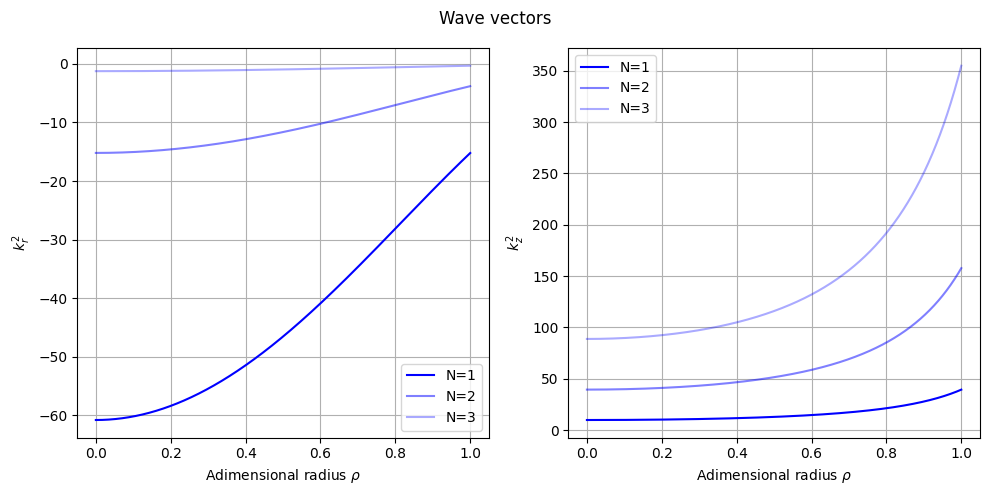

In [103]:
fig, axs = plt.subplots(1, 2, figsize=(10,5))
for n in results["N"]:
    axs[0].plot(rho, results["kr2s"][n-1], color='b', alpha=1/(n), label=f'N={n}')
    axs[1].plot(rho, results["kz2s"][n-1], color='b', alpha=1/(n), label=f'N={n}')
axs[0].set_xlabel(r'Adimensional radius $\rho$')
axs[0].set_ylabel(r'$k_r^{2}$')
axs[0].legend()
axs[0].grid()

axs[1].set_xlabel(r'Adimensional radius $\rho$')
axs[1].set_ylabel(r'$k_z^{2}$')
axs[1].legend()
axs[1].grid()
fig.suptitle('Wave vectors')
plt.tight_layout()

In [ ]:
ct*1e-3/(Rout*1e3)